In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt

# 1. Image Transformations & Scaling (0 to 1)
# الـ ToTensor() لوحدها بتقسم قيم البيكسلز على 255 فبتعمل Scale من 0 لـ 1 تلقائياً
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(), 
    # transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]) # اختياري للـ Transfer Learning
])

# 2. Loading Dataset
# افترضنا إن الداتا متقسمة Folder للـ with_mask و folder للـ without_mask
data_dir = '/kaggle/input/datasets/omkargurav/face-mask-dataset/data' 
full_dataset = datasets.ImageFolder(root=data_dir, transform=transform)

# 3. Splitting Data (80% Train, 20% Validation)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(full_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# 4. Model Architecture (MobileNetV2 is perfect for this task)
model = models.mobilenet_v2(weights='DEFAULT')

# Freeze features if you want Transfer Learning
for param in model.parameters():
    param.requires_grad = False

# Replace the classifier for 2 classes (Mask vs No Mask)
model.classifier[1] = nn.Sequential(
    nn.Linear(model.last_channel, 512),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(512, 2) 
)

# 5. Training Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.classifier.parameters(), lr=0.001)

print(f"Dataset loaded: {len(full_dataset)} images.")
print(f"Classes: {full_dataset.classes}")

Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 110MB/s] 

Dataset loaded: 7553 images.
Classes: ['with_mask', 'without_mask']


In [7]:
import torch
import torch.nn as nn
import torch.optim as optim  # السطر ده هو اللي كان ناقص عشان الـ Adam تشتغل
from torchvision import models

# 1. Define the architecture
model = models.mobilenet_v2(weights='DEFAULT')

# 2. Freeze parameters 
for param in model.parameters():
    param.requires_grad = False

# 3. Adjust the classifier for 2 classes (Mask vs No Mask)
model.classifier[1] = nn.Sequential(
    nn.Linear(model.last_channel, 512),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(512, 2) 
)

# 4. Move to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# 5. Define Loss and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.classifier.parameters(), lr=0.001)

print("All set! Model, Criterion, and Optimizer are defined.")

All set! Model, Criterion, and Optimizer are defined.


In [9]:
import torch
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

# 1. Image Transformations & Scaling (0 to 1)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(), # ده اللي بيعمل Scale لـ [0, 1]
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]) # Normalize لـ ImageNet أوزان الموديل
])

# 2. Loading Dataset
# تأكد إن المسار ده هو اللي فيه الفولدرين (with_mask و without_mask)
data_dir = '/kaggle/input/datasets/omkargurav/face-mask-dataset/data' 
full_dataset = datasets.ImageFolder(root=data_dir, transform=transform)

# 3. Splitting Data (80% Train, 20% Validation)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

# 4. Defining Loaders (هنا الـ Names اللي كانت ناقصة)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print(f"Train loader defined with {len(train_dataset)} images.")
print(f"Validation loader defined with {len(val_dataset)} images.")

Train loader defined with 6042 images.
Validation loader defined with 1511 images.


In [10]:
import time
import copy
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
from torchvision import models
import torch.nn as nn
import torch

num_epochs = 10
best_acc = 0.0
best_model_wts = copy.deepcopy(model.state_dict())

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(num_epochs):
    print(f'Epoch {epoch+1}/{num_epochs}')
    print('-' * 10)

    # Each epoch has a training and validation phase
    for phase in ['train', 'val']:
        if phase == 'train':
            model.train()  # Set model to training mode
            dataloader = train_loader
        else:
            model.eval()   # Set model to evaluate mode
            dataloader = val_loader

        running_loss = 0.0
        running_corrects = 0

        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            # Forward pass
            with torch.set_grad_enabled(phase == 'train'):
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)

                # Backward pass + optimize only if in training phase
                if phase == 'train':
                    loss.backward()
                    optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        epoch_loss = running_loss / len(dataloader.dataset)
        epoch_acc = running_corrects.double() / len(dataloader.dataset)

        print(f'{phase.capitalize()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

        if phase == 'train':
            history['train_loss'].append(epoch_loss)
            history['train_acc'].append(epoch_acc.item())
        else:
            history['val_loss'].append(epoch_loss)
            history['val_acc'].append(epoch_acc.item())

        # Deep copy the best model
        if phase == 'val' and epoch_acc > best_acc:
            best_acc = epoch_acc
            best_model_wts = copy.deepcopy(model.state_dict())

    print()

print(f'Best Val Acc: {best_acc:.4f}')

# Load best model weights
model.load_state_dict(best_model_wts)
torch.save(model.state_dict(), 'best_face_mask_model.pth')

Epoch 1/10
----------


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Train Loss: 0.2023 Acc: 0.9163
Val Loss: 0.1830 Acc: 0.9292

Epoch 2/10
----------
Train Loss: 0.1132 Acc: 0.9573
Val Loss: 0.0475 Acc: 0.9854

Epoch 3/10
----------
Train Loss: 0.0890 Acc: 0.9677
Val Loss: 0.0672 Acc: 0.9775

Epoch 4/10
----------
Train Loss: 0.0839 Acc: 0.9682
Val Loss: 0.0433 Acc: 0.9841

Epoch 5/10
----------
Train Loss: 0.0682 Acc: 0.9737
Val Loss: 0.0458 Acc: 0.9815

Epoch 6/10
----------
Train Loss: 0.0732 Acc: 0.9724
Val Loss: 0.0400 Acc: 0.9848

Epoch 7/10
----------
Train Loss: 0.0718 Acc: 0.9734
Val Loss: 0.0396 Acc: 0.9861

Epoch 8/10
----------
Train Loss: 0.0575 Acc: 0.9798
Val Loss: 0.0322 Acc: 0.9868

Epoch 9/10
----------
Train Loss: 0.0495 Acc: 0.9811
Val Loss: 0.0413 Acc: 0.9815

Epoch 10/10
----------
Train Loss: 0.0578 Acc: 0.9783
Val Loss: 0.0357 Acc: 0.9901

Best Val Acc: 0.9901


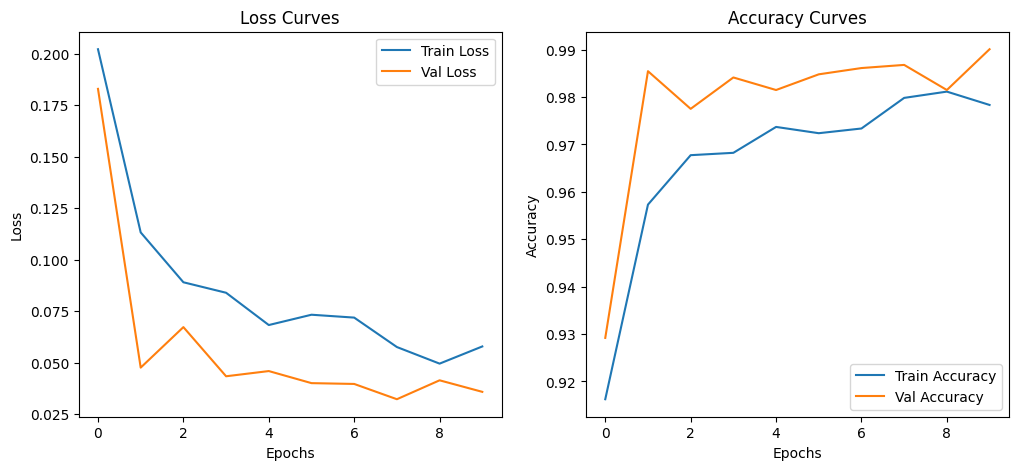

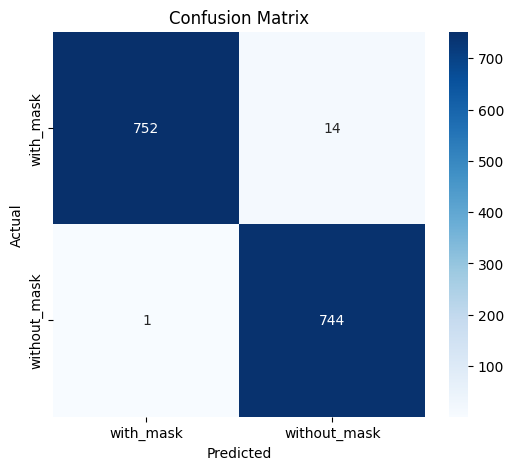

              precision    recall  f1-score   support

   with_mask       1.00      0.98      0.99       766
without_mask       0.98      1.00      0.99       745

    accuracy                           0.99      1511
   macro avg       0.99      0.99      0.99      1511
weighted avg       0.99      0.99      0.99      1511



In [12]:
import matplotlib.pyplot as plt
# 1. Plot Loss and Accuracy Curves
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('Loss Curves')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Accuracy')
plt.plot(history['val_acc'], label='Val Accuracy')
plt.title('Accuracy Curves')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

# 2. Confusion Matrix & Classification Report
all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# Plotting Seaborn Heatmap
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=full_dataset.classes, yticklabels=full_dataset.classes)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

print(classification_report(all_labels, all_preds, target_names=full_dataset.classes))

Prediction: with_mask


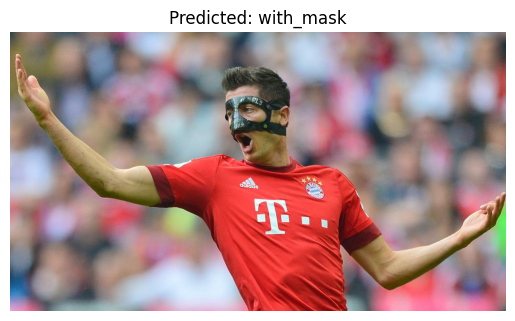

In [13]:
from PIL import Image

def predict_image(image_path, model):
    # 1. Preprocess the image
    img = Image.open(image_path).convert('RGB')
    img_t = transform(img).unsqueeze(0).to(device) # نفس الـ transform اللي عملناه فوق
    
    # 2. Forward pass
    model.eval()
    with torch.no_grad():
        outputs = model(img_t)
        _, preds = torch.max(outputs, 1)
        
    #  Result
    class_names = ['with_mask', 'without_mask']
    print(f'Prediction: {class_names[preds[0]]}')
    
    # forDisplay image
    plt.imshow(img)
    plt.title(f'Predicted: {class_names[preds[0]]}')
    plt.axis('off')
    plt.show()

predict_image('/kaggle/input/datasets/omarsalman77/predictmask/robert-lewandowski-wearing-a-mask.jpg', model)

Prediction: with_mask


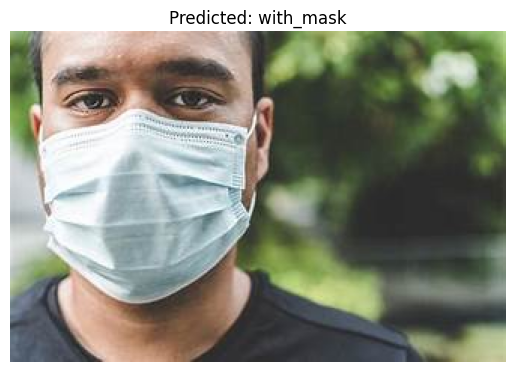

In [14]:
from PIL import Image

def predict_image(image_path, model):
    # 1. Preprocess the image
    img = Image.open(image_path).convert('RGB')
    img_t = transform(img).unsqueeze(0).to(device) # نفس الـ transform اللي عملناه فوق
    
    # 2. Forward pass
    model.eval()
    with torch.no_grad():
        outputs = model(img_t)
        _, preds = torch.max(outputs, 1)
        
    # 3. Result
    class_names = ['with_mask', 'without_mask']
    print(f'Prediction: {class_names[preds[0]]}')
    
    # Display image
    plt.imshow(img)
    plt.title(f'Predicted: {class_names[preds[0]]}')
    plt.axis('off')
    plt.show()

# جربه على صورة من عندك
predict_image('/kaggle/input/datasets/omarsalman77/predictmask/OIP (1).jpg', model)

Prediction: without_mask


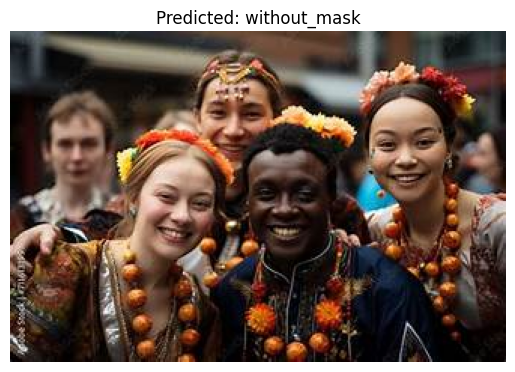

In [15]:
from PIL import Image

def predict_image(image_path, model):
    # 1. Preprocess the image
    img = Image.open(image_path).convert('RGB')
    img_t = transform(img).unsqueeze(0).to(device) # نفس الـ transform اللي عملناه فوق
    
    # 2. Forward pass
    model.eval()
    with torch.no_grad():
        outputs = model(img_t)
        _, preds = torch.max(outputs, 1)
        
    # 3. Result
    class_names = ['with_mask', 'without_mask']
    print(f'Prediction: {class_names[preds[0]]}')
    
    # Display image
    plt.imshow(img)
    plt.title(f'Predicted: {class_names[preds[0]]}')
    plt.axis('off')
    plt.show()

# جربه على صورة من عندك
predict_image('/kaggle/input/datasets/omarsalman77/predictmask/OIP n(2).jpg', model)

Prediction: without_mask


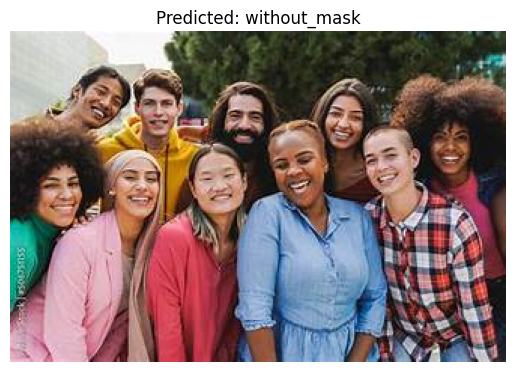

In [16]:
from PIL import Image

def predict_image(image_path, model):
    # 1. Preprocess the image
    img = Image.open(image_path).convert('RGB')
    img_t = transform(img).unsqueeze(0).to(device) # نفس الـ transform اللي عملناه فوق
    
    # 2. Forward pass
    model.eval()
    with torch.no_grad():
        outputs = model(img_t)
        _, preds = torch.max(outputs, 1)
        
    # 3. Result
    class_names = ['with_mask', 'without_mask']
    print(f'Prediction: {class_names[preds[0]]}')
    
    # Display image
    plt.imshow(img)
    plt.title(f'Predicted: {class_names[preds[0]]}')
    plt.axis('off')
    plt.show()

# جربه على صورة من عندك
predict_image('/kaggle/input/datasets/omarsalman77/predictmask/OIP nn(2).jpg', model)

Prediction: with_mask


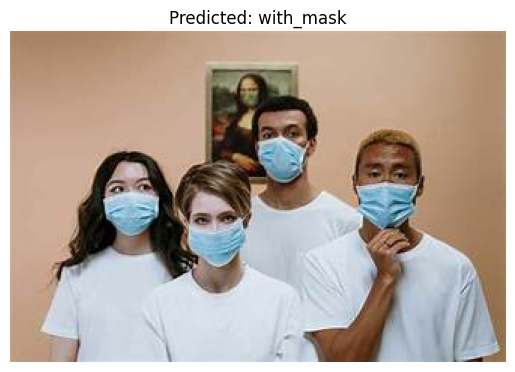

In [17]:
from PIL import Image

def predict_image(image_path, model):
    # 1. Preprocess the image
    img = Image.open(image_path).convert('RGB')
    img_t = transform(img).unsqueeze(0).to(device) # نفس الـ transform اللي عملناه فوق
    
    # 2. Forward pass
    model.eval()
    with torch.no_grad():
        outputs = model(img_t)
        _, preds = torch.max(outputs, 1)
        
    # 3. Result
    class_names = ['with_mask', 'without_mask']
    print(f'Prediction: {class_names[preds[0]]}')
    
    # Display image
    plt.imshow(img)
    plt.title(f'Predicted: {class_names[preds[0]]}')
    plt.axis('off')
    plt.show()

# جربه على صورة من عندك
predict_image('//kaggle/input/datasets/omarsalman77/predictmask/OIP.jpg', model)